# Experiment 4 : Spatial Signaling and Proliferation

**Drug Modeled:** Gefitinib

**Condition Tested:** EGFR signaling and proliferation rates in a drug gradient

**Research Question:** How do spatial drug gradients create biological response gradients?

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters

# Tissue depth range (cm)
L = 0.2             # 2 mm

# Number of spatial points
nx = 200

x = np.linspace(0, L, nx)
dx = x[1] - x[0]

# Total simulation time (s)
T = 3600            # 1 hour

# Number of time steps
nt = 5000

dt = T / nt

# Layer boundaries (cm)
boundary_1 = 0.05   # 0.5 mm
boundary_2 = 0.12   # 1.2 mm

# Diffusion coefficients for each layer (cm^2/s)
D1 = 5e-7           # Outer tumor region
D2 = 1e-7           # Dense / diffusion-limited region
D3 = 5e-7           # Deeper tumor region

# Spatial diffusitivity profile
D = np.full(nx, D1)

D[x >= boundary_1] = D2
D[x >= boundary_2] = D3

# Constant drug source at vessel boundary
C_source = 1.0

# Saving buffer
save_every = 25

In [2]:
# Solving heterogenous profile

C = np.zeros(nx)
C[0] = C_source

saved_profiles = []

# Time-stepping loop
for t in range(nt):
    C_new = C.copy()

    for i in range(1, nx - 1):
        # diffusitivies
        D_left = (D[i] + D[i-1]) / 2
        D_right = (D[i] + D[i+1]) / 2

        # diffusion fluxes
        J_left = -D_left * (C[i] - C[i-1]) / dx
        J_right = -D_right * (C[i+1] - C[i]) / dx

        # update concentration
        C_new[i] = C[i] + (dt / dx) * (J_left - J_right)

    C = C_new

    # Re-apply source boundary condition
    C[0] = C_source

    if (t % save_every) == 0:
        saved_profiles.append(C.copy())

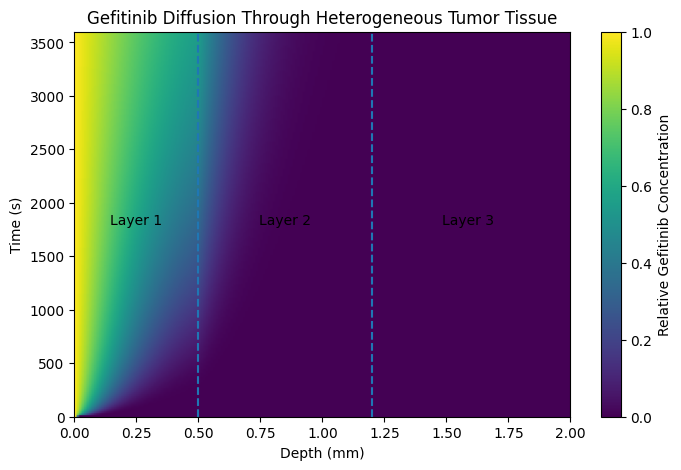

In [3]:
# Plot

C_field = np.array(saved_profiles)

plt.figure(figsize=(8, 5))

plt.imshow(C_field, aspect='auto', origin='lower', extent=[0, L * 10, 0, T])

# Labels and formatting

plt.colorbar(label='Relative Gefitinib Concentration')

plt.xlabel('Depth (mm)')
plt.ylabel('Time (s)')

plt.title('Gefitinib Diffusion Through Heterogeneous Tumor Tissue')

plt.axvline(boundary_1 * 10, linestyle='--')
plt.axvline(boundary_2 * 10, linestyle='--')

plt.savefig(
    'figures/exp04_heter_map_baseline.png',
    dpi=150,
    bbox_inches='tight'
)

plt.annotate('Layer 1', xy=(boundary_1 * 5, T / 2), fontsize=10, ha='center')
plt.annotate('Layer 2', xy=((boundary_1 + boundary_2) * 5, T / 2), fontsize=10, ha='center')
plt.annotate('Layer 3', xy=((boundary_1 + boundary_2 + L) * 8.57 / 2, T / 2), fontsize=10, ha='center')

plt.show()

## Figure 4A

**Figure 4A.** Spatial distribution of normalized gefitinib concentration within heterogeneous tumor tissue used as the input to the signaling model. The concentration field was generated using the heterogeneous diffusion model developed in Experiment 2 and serves as the basis for predicting spatial patterns of EGFR inhibition, ERK signaling activity, and cellular proliferation.

### Observations

* Highest gefitinib concentrations occur adjacent to the blood vessel.
* Concentration decreases with increasing tissue depth.
* The dense middle layer produces reduced drug penetration into deeper tissue.
* Spatial concentration gradients persist throughout the tumor.

### Interpretation

The concentration field represents the local drug exposure experienced by cells throughout the tumor. Because EGFR inhibition depends on local gefitinib concentration, different regions are expected to experience different levels of receptor inhibition. The heterogeneous concentration distribution establishes the initial conditions for downstream signaling analysis.

### Discussion

The heterogeneous concentration field generated in Experiment 2 provides the spatial input for the pharmacodynamic model. Regions of reduced drug concentration are therefore expected to exhibit reduced EGFR inhibition relative to areas proximal to the vascular source.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Paramters

# New copy of concentration field from figure 4A
C_gefit_field = C_field

# Hill coefficient
n = 1

# Literature IC_50 value, concentration of gefitinib to achieve 50% inhibition of EGFR
ic_50 = 0.3

# Layer boundaries (cm)
boundary_1 = 0.05   # 0.5 mm
boundary_2 = 0.12   # 1.2 mm

In [5]:
# Solving for EGFR inhibition field

# Applying Hill equation
EGFR_activity = 1 / (1 + (C_gefit_field / ic_50) ** n)

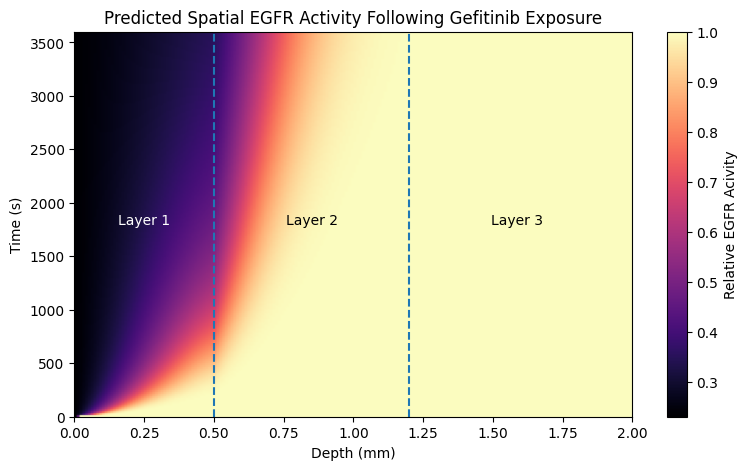

In [6]:
# Plot

plt.figure(figsize=(9, 5))

plt.imshow(EGFR_activity, aspect='auto', origin='lower', 
            extent=[0, L * 10, 0, T], cmap='magma')

# Labels and formatting

plt.colorbar(label='Relative EGFR Acivity')

plt.xlabel('Depth (mm)')
plt.ylabel('Time (s)')

plt.title('Predicted Spatial EGFR Activity Following Gefitinib Exposure')

plt.axvline(boundary_1 * 10, linestyle='--')
plt.axvline(boundary_2 * 10, linestyle='--')

plt.savefig(
    'figures/exp04_EGFR_inhib_field', 
    dpi=150,
    bbox_inches='tight'
)

plt.annotate('Layer 1', xy=(boundary_1 * 5, T / 2), fontsize=10, ha='center', color='white')
plt.annotate('Layer 2', xy=((boundary_1 + boundary_2) * 5, T / 2), fontsize=10, ha='center')
plt.annotate('Layer 3', xy=((boundary_1 + boundary_2 + L) * 8.57 / 2, T / 2), fontsize=10, ha='center')

plt.show()

## Figure 4B

**Figure 4B.** Predicted spatial distribution of relative EGFR activity following application of the Hill inhibition model to the heterogeneous gefitinib concentration field. Regions exposed to higher gefitinib concentrations exhibit greater EGFR inhibition (lower relative activity), while deeper regions receiving reduced drug exposure retain higher receptor activity. The nonlinear concentration–response relationship amplifies differences in receptor activity near the IC₅₀, producing spatially heterogeneous signaling across the tumor.

### Observations

* Application of the Hill inhibition model transformed the heterogeneous gefitinib concentration field into a corresponding spatial map of relative EGFR activity
* Regions adjacent to the vascular source exhibited the lowest EGFR activity due to high local drug concentrations, whereas receptor activity progressively increased with tissue depth as gefitinib concentrations declined
* The transition from inhibited to active receptor states occurred most prominently near the dense tissue layer, where reductions in drug penetration produced a noticeable spatial shift in EGFR activity

### Interpretation

The results demonstrate that spatial variability in drug exposure directly generates heterogeneous EGFR inhibition throughout the tumor. Because the Hill equation describes a nonlinear concentration–response relationship, receptor activity changes most rapidly when local gefitinib concentrations approach the IC₅₀. Consequently, relatively modest concentration differences produced by heterogeneous diffusion are translated into substantially larger differences in receptor activity. This establishes EGFR signaling as the first biological process through which physical transport heterogeneity influences cellular behavior.

### Discussion

The predicted EGFR activity field provides a mechanistic link between drug transport and downstream signaling. Although all tumor regions are exposed to the same vascular drug source, heterogeneous tissue structure generates unequal local concentrations that produce distinct levels of receptor inhibition across the tissue. These results suggest that transport limitations alone may permit portions of a tumor to maintain significant EGFR signaling despite targeted therapy, potentially contributing to spatially heterogeneous therapeutic responses. The EGFR activity map therefore serves as the biological input for subsequent modeling of ERK signaling and proliferation, allowing the downstream consequences of diffusion-mediated heterogeneity to be quantitatively investigated.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Paramters

# ERK activation rate constant
k_act = 0.1

# ERK deactivation rate constant
k_deact = 0.3

# Effective signal gain, balance between ERK activation/deactivation
alpha = k_act / k_deact

# ERK activity profile
ERK_activity = alpha * EGFR_activity

**Note:** These parameters arise from the use of a first-order ODE to represent the activity of ERK (Extracellular Signal-Regulated Kinase) through the EGFR signaling pathway. The full equation is : 

$$\frac{dERK}{dt} = k_{act} * EGFR - k_{deact} * ERK$$

In particular, the solution presented in this experiment is a steady-state solution, where the first-order ERK-time derivative is set to $0$. This creates an equilibrium between ERK activation and deactivation, and solving the equation for ERK yields the following :

$$ERK = \frac{k_{act}}{k_{deact}} * EGFR$$

Additionally, the term $\frac{k_{act}}{k_{deact}}$ has been exchanged for $\alpha$, and acts as a 'signal gain' constant derived from the ratio of the two rate constants, amplifying or reducing the activity.

So, in all, the final equation used here is as written :

$$ERK = \alpha * EGFR$$

$$\alpha = \frac{k_{act}}{k_{deact}}$$

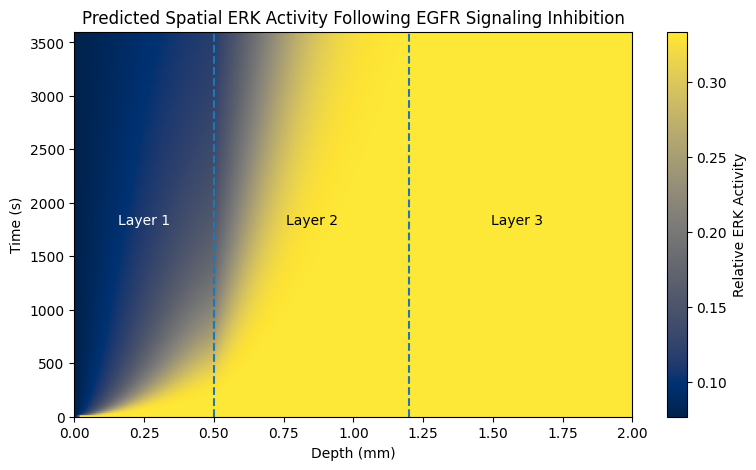

In [8]:
# Plot

plt.figure(figsize=(9,5))

plt.imshow(ERK_activity, aspect='auto', origin='lower', 
            extent=[0, L * 10, 0, T], cmap='cividis')

# Labels and formatting

plt.colorbar(label='Relative ERK Activity')

plt.xlabel('Depth (mm)')
plt.ylabel('Time (s)')

plt.title('Predicted Spatial ERK Activity Following EGFR Signaling Inhibition')

plt.axvline(boundary_1 * 10, linestyle='--')
plt.axvline(boundary_2 * 10, linestyle='--')

plt.savefig(
    'figures/exp04_ERK_activity_field', 
    dpi=150,
    bbox_inches='tight'
)

plt.annotate('Layer 1', xy=(boundary_1 * 5, T / 2), fontsize=10, ha='center', color='white')
plt.annotate('Layer 2', xy=((boundary_1 + boundary_2) * 5, T / 2), fontsize=10, ha='center')
plt.annotate('Layer 3', xy=((boundary_1 + boundary_2 + L) * 8.57 / 2, T / 2), fontsize=10, ha='center')

plt.show()

## Figure 4C

**Figure 4C.** Predicted spatial distribution of relative ERK signaling activity calculated using the steady-state solution of a first-order activation–deactivation signaling model. ERK activity is assumed to rapidly equilibrate with local EGFR activity, allowing downstream signaling to be estimated as a function of receptor activation. Regions with stronger EGFR inhibition exhibit correspondingly reduced ERK signaling, while areas receiving lower drug exposure retain higher signaling activity.

### Observations

* The spatial distribution of ERK activity closely followed the predicted EGFR activity field
* Regions adjacent to the vascular source exhibited the lowest ERK activity due to strong upstream EGFR inhibition
* ERK signaling progressively increased with tissue depth as local drug concentrations declined
* The transition in ERK activity remained most pronounced across the dense tissue layer (emphasizes the importance of heterogenous drug diffusion on intracellular signaling)

### Interpretation

The steady-state signaling model demonstrates that spatial differences in receptor inhibition propagate directly into the intracellular signaling network. Because ERK activity is determined by the balance between activation and deactivation processes, regions experiencing greater EGFR inhibition maintain correspondingly lower ERK signaling. Although simplified, this first-order model captures the essential relationship between receptor activity and downstream pathway output while preserving the mechanistic link between drug transport and cellular signaling.

### Discussion

The ERK activity field represents the first intracellular consequence of heterogeneous gefitinib delivery. Rather than modeling the complete RAS–RAF–MEK–ERK cascade, the present model approximates ERK dynamics using a first-order activation–deactivation process under a quasi-steady-state assumption. This approach preserves the biological role of ERK as the primary downstream effector of EGFR signaling while avoiding unnecessary complexity and parameter uncertainty.

The quasi-steady-state assumption is appropriate for the present study because the objective is to characterize spatial differences in signaling activity rather than transient intracellular dynamics.

The resulting ERK activity map provides the signaling input for the proliferation model, allowing the effects of spatially heterogeneous pathway inhibition to be translated into predicted differences in cellular proliferation.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters

# Proliferation Hill coefficient
m = 4

# Half-maximal ERK activity
K = 0.5

# Proliferation rate profile
P_rate = (ERK_activity ** m) / ((K ** m) + (ERK_activity ** m))

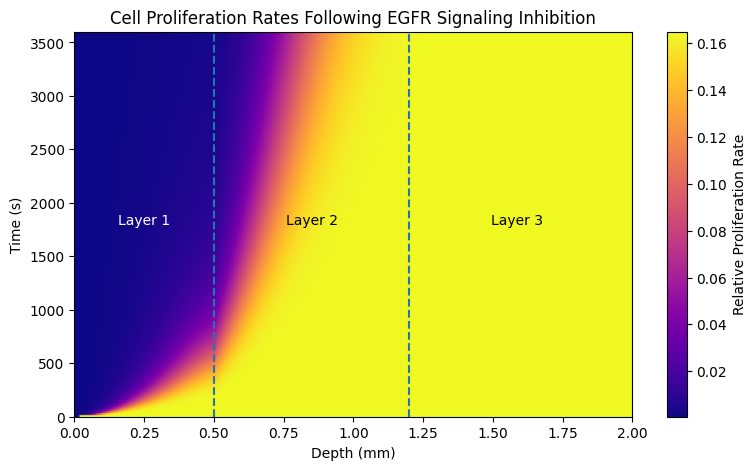

In [10]:
# Plot

plt.figure(figsize=(9,5))

plt.imshow(P_rate, aspect='auto', origin='lower', 
            extent=[0, L * 10, 0, T], cmap='plasma')

# Labels and formatting

plt.colorbar(label='Relative Proliferation Rate')

plt.xlabel('Depth (mm)')
plt.ylabel('Time (s)')

plt.title('Cell Proliferation Rates Following EGFR Signaling Inhibition')

plt.axvline(boundary_1 * 10, linestyle='--')
plt.axvline(boundary_2 * 10, linestyle='--')

plt.savefig(
    'figures/exp04_prolif_field', 
    dpi=150,
    bbox_inches='tight'
)

plt.annotate('Layer 1', xy=(boundary_1 * 5, T / 2), fontsize=10, ha='center', color='white')
plt.annotate('Layer 2', xy=((boundary_1 + boundary_2) * 5, T / 2), fontsize=10, ha='center')
plt.annotate('Layer 3', xy=((boundary_1 + boundary_2 + L) * 8.57 / 2, T / 2), fontsize=10, ha='center')

plt.show()

## Figure 4D

**Figure 4D.** Predicted spatial distribution of relative cellular proliferation following propagation of heterogeneous gefitinib exposure through EGFR inhibition and downstream ERK signaling. Relative proliferation was estimated using a Hill-type response model relating ERK activity to cell-cycle progression. Regions experiencing stronger pathway suppression exhibited reduced proliferative activity, whereas areas with limited drug penetration retained higher predicted proliferation.

### Observations

Relative proliferation was lowest in regions adjacent to the vascular source, where gefitinib concentrations and EGFR inhibition were greatest. Proliferation progressively increased with tissue depth as drug concentrations declined and ERK signaling recovered. The dense middle tissue layer produced a distinct transition in proliferative activity, resulting in pronounced spatial heterogeneity across the tumor.

### Interpretation

The proliferation map demonstrates how physical transport heterogeneity ultimately translates into heterogeneous cellular behavior. While diffusion establishes concentration gradients and EGFR inhibition modifies receptor activity, the downstream signaling cascade determines the extent to which these molecular changes influence cell-cycle progression. The nonlinear proliferation response further amplifies differences in signaling activity, producing localized regions of reduced and sustained cellular proliferation.

### Discussion

The predicted proliferation field directly addresses the central research question by illustrating how heterogeneous gefitinib transport can generate spatially heterogeneous therapeutic responses within an L858R-mutant NSCLC tumor. Despite uniform drug administration from the vascular boundary, variations in tissue transport produce unequal pathway inhibition that propagates through EGFR and ERK signaling to influence cellular proliferation. These findings suggest that transport-limited regions may remain proliferative even when neighboring tissue experiences substantial pathway suppression. More broadly, the model highlights the importance of integrating physical transport processes with intracellular signaling when evaluating targeted therapy efficacy and provides a framework that can be extended to incorporate additional biological mechanisms or alternative therapeutic strategies.